## Input-Ouput (IO) curve

Authors: Armando Romani, Open Brain Institute

Last Modified: 05.2026

In this notebook, we plot the input-output curve of a single hippocampus neuron in terms of number of spikes versus current amplitude.

Let's first import some libraries:

In [9]:
from obi_auth import get_token
from entitysdk.client import Client
from entitysdk.common import ProjectContext
from entitysdk.models import Simulation, SimulationCampaign, SimulationResult, SimulationExecution
from ipywidgets import interact
from campaign_helpers import get_percent_start
from plot_compare_traces import plot_comparison
from obi_auth import get_token
from obi_notebook.get_projects import get_projects
from obi_notebook.get_environment import get_environment
from ipywidgets import widgets
from uuid import UUID
from campaign_helpers import stage_sim_campaign
import json

import pandas as pd
from campaign_helpers import extract_features_from_simulation

import matplotlib.pyplot as plt

## Get authentication token and choose a project context

Select __Hippocampus single neuron simulations__ as project

In [2]:
env = "production"
token = get_token(environment=env, auth_mode="daf")
project_context = get_projects(token=token, env=env)

Device Authentication Required

1. Click on authentication URL
2. Complete authentication in browser
3. Return here when done

Authentication URL:
]8;id=16378852;https://cell-a.openbraininstitute.org/auth/realms/SBO/device?user_code=JOPK-VIFH\https://cell-a.openbraininstitute.org/auth/realms/SBO/device?user_code=JOPK-VIFH]8;;\

   ✓ Authentication completed successfully!


Dropdown(description='Select:', options=(('Testing', {'id': '5ce8c7db-8847-499b-89b2-95612edafad2', 'name': 'T…

## Select SimulationCampaigns

In this case, we first tested a range of input strengths (90-200% of threshold current). Then we realized that this range produces only a subset of the possibile frequency the neuron is capable of and we decided to test another range (210-260%). In the following code we find and select both campaigns, and we merge the results.

In [3]:
sim1_id = UUID("75a120ce-baec-4b17-ad0e-3d51182a9de6") # range 90-200
sim2_id = UUID("736ab997-c3c2-40fa-b8ea-3a3ceb2aad48") # range 210-260

In [4]:
client = Client(environment=env, project_context=project_context, token_manager=token)

sims1 = client.search_entity(entity_type=SimulationCampaign, query={
    "id": sim1_id, "authorized_project_id": project_context.project_id
}).all()
sims2 = client.search_entity(entity_type=SimulationCampaign, query={
    "id": sim2_id, "authorized_project_id": project_context.project_id
}).all()

sel_sims1 = widgets.Dropdown(options=[(sim_.name, sim_.id) for sim_ in sims1],
                                description="Sim 1:")
sel_sims2 = widgets.Dropdown(options=[(sim_.name, sim_.id) for sim_ in sims2],
                                description="Sim 2:")
display(widgets.HTML("Select the two simulation campaigns:"))
display(sel_sims1)
display(sel_sims2)

HTML(value='Select the two simulation campaigns:')

Dropdown(description='Sim 1:', options=(('IO of a single PC', UUID('75a120ce-baec-4b17-ad0e-3d51182a9de6')),),…

Dropdown(description='Sim 2:', options=(('IO of a single PC', UUID('736ab997-c3c2-40fa-b8ea-3a3ceb2aad48')),),…

# Inspect single neuron traces

This downloads the simulation campaign data from the OBI platform into this notebook.

In [5]:
sims1 = stage_sim_campaign(client, sel_sims1.value,
                                         output_dir=f"./simulation_results/{sel_sims1.value}")
sims2 = stage_sim_campaign(client, sel_sims2.value,
                                          output_dir=f"./simulation_results/{sel_sims2.value}")

We can merge the two simulation campaigns

In [6]:
sims = sims1 + sims2

In [8]:
# Build a mapping of percent_start to simulation paths
control_map = {
    get_percent_start(sim_path): sim_path for sim_path in sims
}

# Find common percent_start values between control and mutation
steps = sorted(set(control_map.keys()))

# Create single dropdown for selecting stimulus step
step_dropdown = widgets.Dropdown(
    options=[(f"Step_{int(step)}", step) for step in steps],
    description='Stimulus:',
)

# Create the interactive interface
display(widgets.HTML(f"""Loaded {len(steps)} matching stimulus steps<br>
Available steps: {', '.join([f'Step_{int(s)}' for s in steps])}<br>
Use the dropdown menu above to select a stimulus step and compare control vs mutation"""))
interactive_plot_fun = plot_comparison(control_map)
interact(interactive_plot_fun, percent_start=step_dropdown)

HTML(value='Loaded 18 matching stimulus steps<br>\nAvailable steps: Step_90, Step_100, Step_110, Step_120, Ste…

interactive(children=(Dropdown(description='Stimulus:', options=(('Step_90', 90.0), ('Step_100', 100.0), ('Ste…

<function plot_compare_traces.plot_comparison.<locals>.plot_func_(percent_start)>

## Plot input-output curve

Now we'll use eFEL to extract electrophysiological features from all simulations.

In [12]:
# Extract features for all control simulations
control_features = []
for i, sim_path in enumerate(sims):
    features = extract_features_from_simulation(sim_path)
    features['campaign'] = 'control'
    features['sim_index'] = i
    control_features.append(features)

# Combine into a DataFrame for easy analysis
all_features = control_features
features_df = pd.DataFrame(all_features)

# Sort by percent_start and campaign
features_df = features_df.sort_values(['percent_start', 'campaign'])

features_df.head()

,percent_start,stim_start,stim_end,spike_count,campaign,sim_index
2,90.0,500.0,2500.0,0,control,2
10,100.0,500.0,2500.0,1,control,10
6,110.0,500.0,2500.0,1,control,6
11,120.0,500.0,2500.0,1,control,11
0,130.0,500.0,2500.0,1,control,0


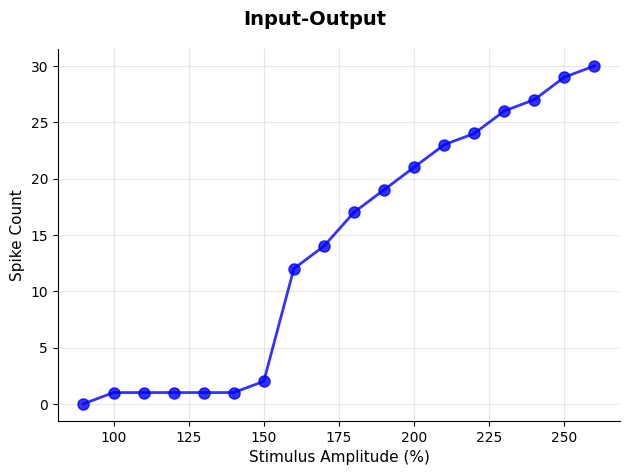

In [19]:
fig, ax = plt.subplots()

# Features to plot
features_to_plot = [
    ('spike_count', 'Spike Count'),
]
    
# Get control data
control_data = features_df[features_df['campaign'] == 'control']

# Plot control
ax.plot(control_data['percent_start'], control_data['spike_count'], 
        'o-', color='blue', linewidth=2, markersize=8, label='Control', alpha=0.8)

# Format plot
ax.set_xlabel('Stimulus Amplitude (%)', fontsize=11)
ax.set_ylabel('Spike Count', fontsize=11)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Input-Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()